# Image Compression

In [1]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

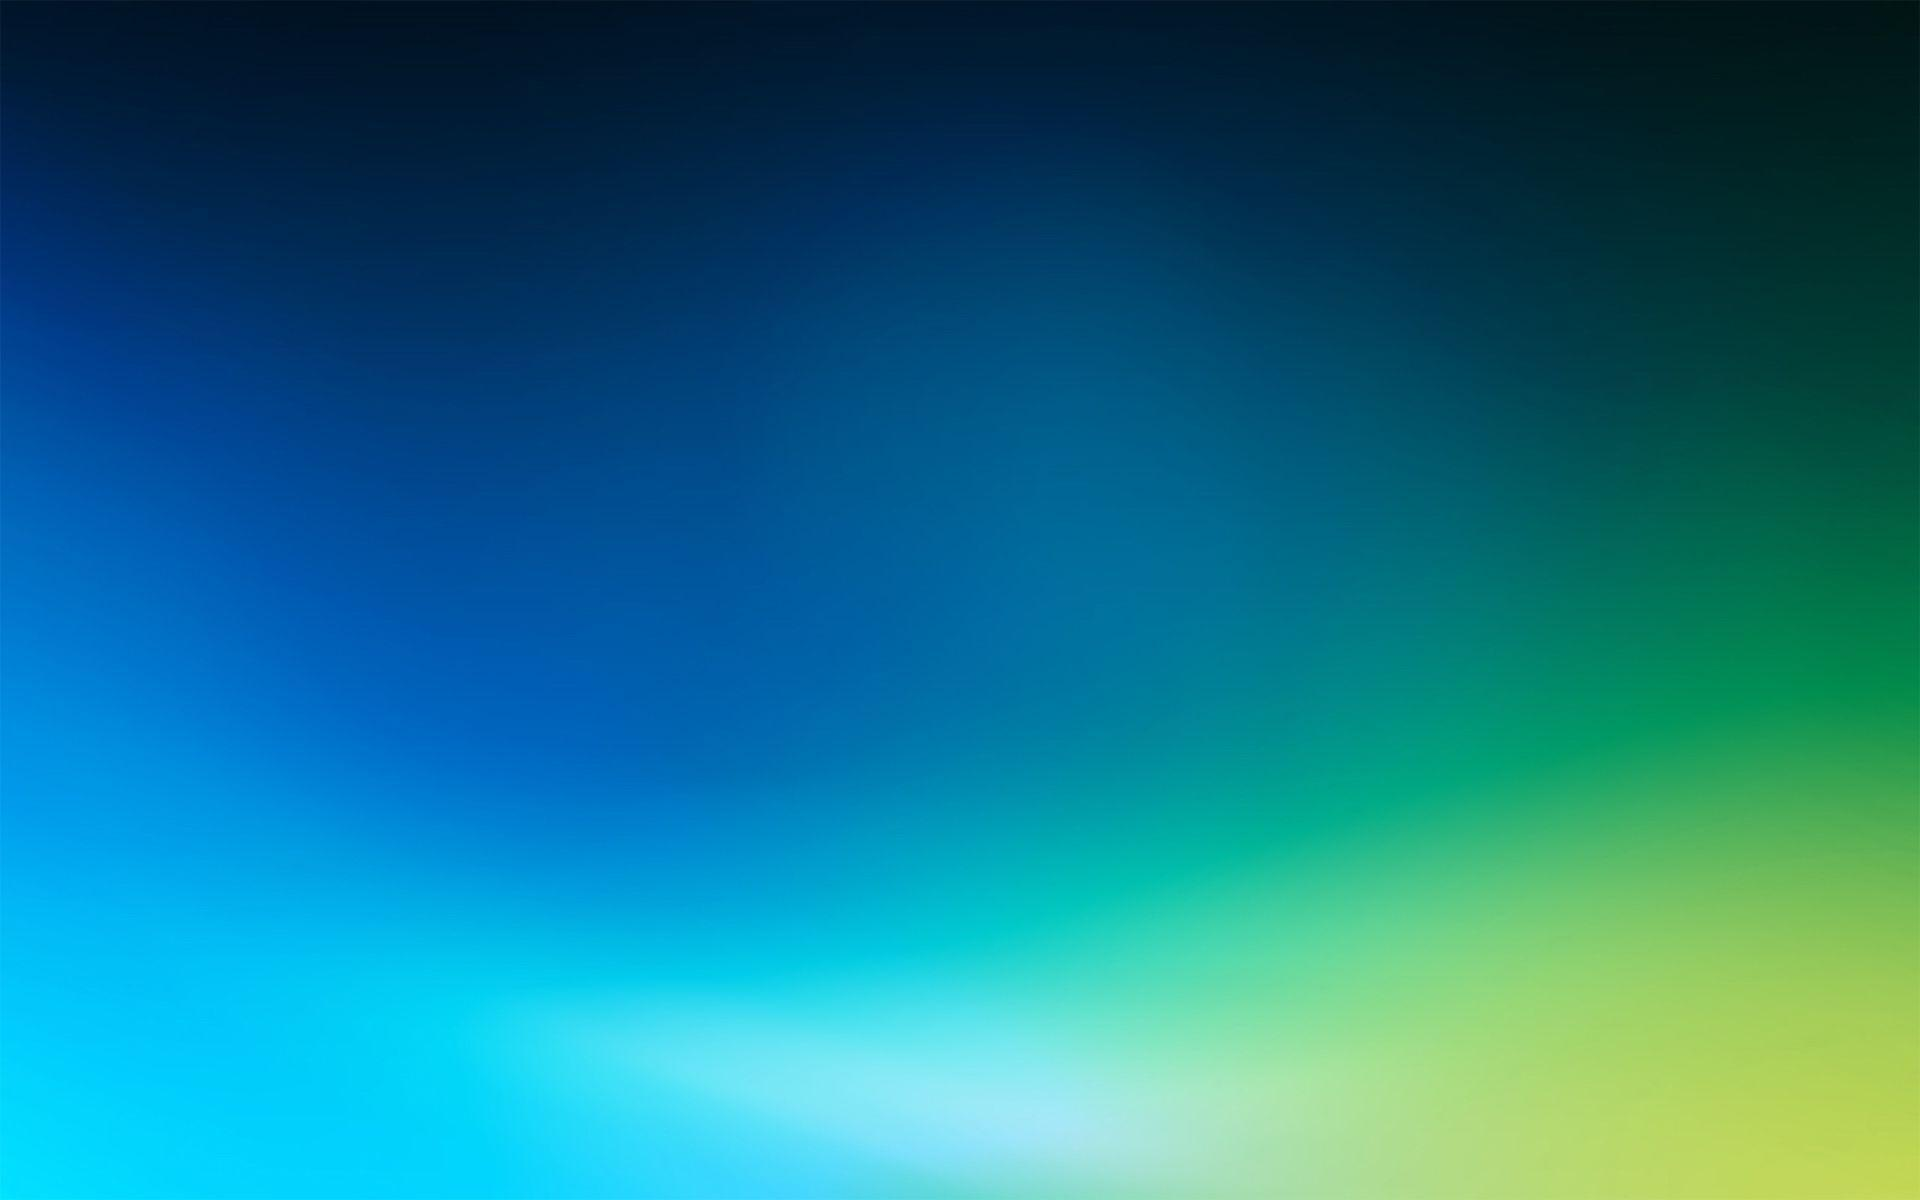

In [2]:
img = Image.open('img.jpg')
img

## Resize the image

We resize the image to make our model run faster.

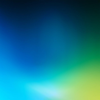

In [10]:
img2 = img.resize((100, 100))
img2

## Convert to array

In [11]:
arr = np.array(img2)
arr.shape

(100, 100, 3)

## Reshape Array

Now, we reshape the array into two dimensions. This is done so KMeans can work properly.

In [12]:
features = arr.reshape(-1, 3)
features.shape

(10000, 3)

## Find K

Now, we find the best K using the elbow method and silhoutte score.

### 1. Elbow Method

In [13]:
K = [2, 4, 8, 16, 32, 64, 128] # test K
inr = []  # store inertias
for i in K:
    kmeans = KMeans(n_clusters=i, random_state=42)
    labels = kmeans.fit_predict(features)
    inr.append(kmeans.inertia_)
print(f'Inertias: {inr}')

Inertias: [55244700.42298456, 19222021.90303593, 8391079.196812857, 3906648.3675516867, 1790291.8083280218, 863619.2394593272, 424837.2580469503]


#### Plot graph

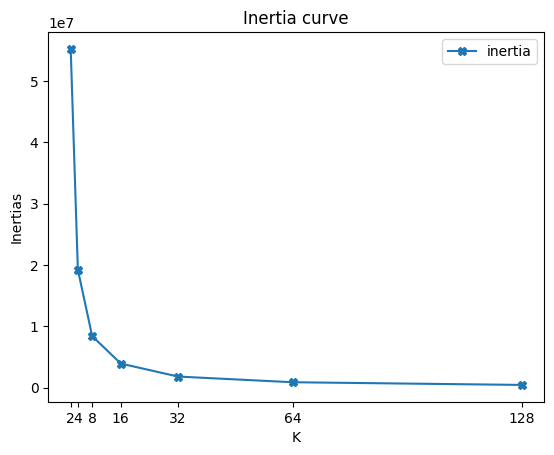

In [14]:
plt.plot(K, inr, label = 'inertia', marker = 'X')
plt.title('Inertia curve')
plt.xlabel('K')
plt.xticks(K)
plt.ylabel('Inertias')
plt.legend()
plt.show()

According to the graph, K should be either 8 or 16. Now, Let's check again with Silhoutte score.

### 2. Silhoutte Score

In [16]:
slh = []
K = [2, 4, 8, 16, 32, 64, 128]
for i in K:
    kmeans = KMeans(n_clusters=i, random_state=42)
    labels = kmeans.fit_predict(features)
    slh.append(silhouette_score(features, labels))
max_score = slh.index(max(slh))
print(f'Scores: {slh}')
print(f'Max score: {slh[max_score]}, K: {K[max_score]}')

Scores: [0.49687998850102694, 0.5078315856838926, 0.4602159666900099, 0.40962173543024566, 0.40319888607842297, 0.37068819207958287, 0.35873456756519057]
Max score: 0.5078315856838926, K: 4


Here, we observe that silhouette score and elbow method contradict each other. Elbow method shows 8 as the optimal solution. Whereas, silhouette score evaluation outputs 4 as the highest score. Therefore, we will evaluate this now using human perception.

### 3. Plot different K

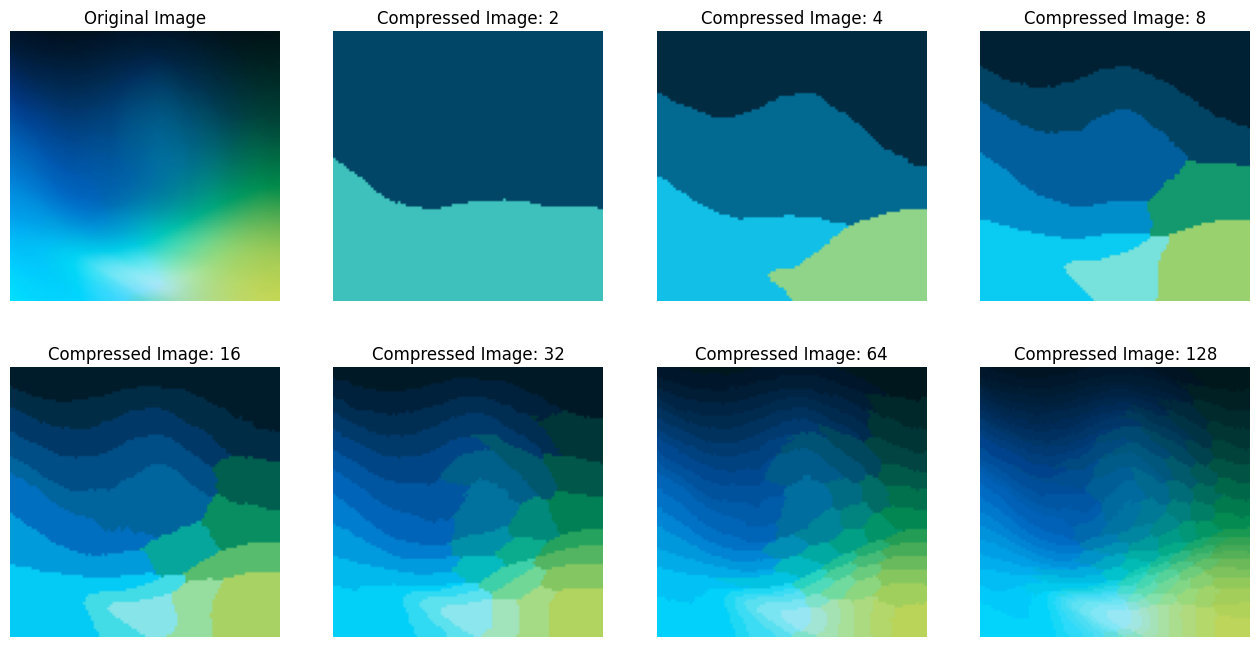

In [21]:
K = [2, 4, 8, 16, 32, 64, 128]

# original
fig, axes = plt.subplots(2, 4, figsize = (16, 8))
axes = axes.flatten()
axes[0].imshow(arr)
axes[0].axis("off")
axes[0].set_title("Original Image")
for i in range(len(K)):
    # Train model
    kmeans = KMeans(n_clusters = K[i], random_state=42)
    labels = kmeans.fit_predict(features)
    centr = kmeans.cluster_centers_

    # Create compressed image
    comp_img = centr[labels]
    comp_img = comp_img.reshape(100, 100, 3)
    comp_img = comp_img.astype(np.uint8)
    
    # compressed
    axes[i+1].imshow(comp_img)
    axes[i+1].axis("off")
    axes[i+1].set_title(f"Compressed Image: {K[i]}")

## Conclusion

After visually inspecting the compressed images for all K values
`[2, 4, 8, 16, 32, 64, 128]`, the following conclusions were drawn:

- **K=128** produced the best visual quality, closest to the original.
- **K=16** was the best trade-off between quality and compression.

Since the goal of image compression is to **reduce size while maintaining acceptable quality**, **K=16** is chosen as the final K over K=128. Despite K=128 looking better, it uses 8x more colors, meaning less compression.

## Training

### Resize Again

We resize the image to `(256, 256)` for better results.

In [22]:
img_256 = img.resize((256, 256))
array = np.array(img)
features = array.reshape(-1, 3)

In [23]:
k = 16
model = KMeans(n_clusters = k, random_state = 42)
labels = model.fit_predict(features)
centr = model.cluster_centers_
new_arr = centr[labels]
new_arr = new_arr.reshape(256, 256, 3)
new_arr = new_arr.astype(np.uint8)

## Compare

Plot original and compressed image side by side.

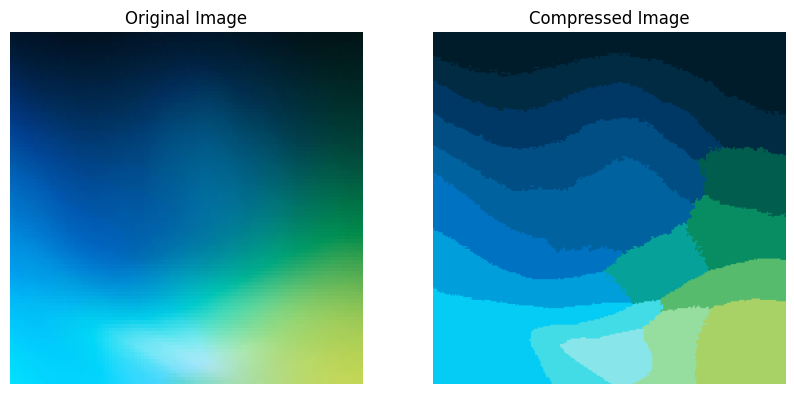

In [25]:
# original
fig, axes = plt.subplots(1, 2, figsize = (10, 5))
axes[0].imshow(arr)
axes[0].axis("off")
axes[0].set_title("Original Image")

# compressed
axes[1].imshow(new_arr)
axes[1].axis("off")
axes[1].set_title("Compressed Image")

plt.show()